# Taller BCI Simulado – Control Visual con Señales EEG Artificiales

**Nombre:** 
* Joan Sebastian Roberto Puerto
* Baruj Vladimir Ramírez Escalante
* Diego Alberto Romero Olmos
* Maicol Sebastian Olarte Ramirez
* Jorge Isaac Alandete Díaz 

**Fecha:** 23/04/2026

## Objetivo
Simular una interfaz cerebro-computadora (BCI) usando señales EEG sintéticas, aplicando filtros de frecuencia y generando una respuesta visual basada en el nivel de atención.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

## 1. Generación de señal EEG simulada

In [44]:
# Parámetros
fs = 250  # Hz
duracion = 15  # segundos
t = np.linspace(0, duracion, fs * duracion)

# Señales base
alpha = 0.5 * np.sin(2 * np.pi * 10 * t)  # 10 Hz (Alpha)
beta = 0.3 * np.sin(2 * np.pi * 20 * t)   # 20 Hz (Beta)

# Ruido
ruido = 0.2 * np.random.randn(len(t))

# Simular "atención" aumentando Alpha en ciertos intervalos
alpha_mod = alpha.copy()
alpha_mod[(t > 4) & (t < 7)] *= 2
alpha_mod[(t > 10) & (t < 13)] *= 2.5

# Señal final
eeg = alpha_mod + beta + ruido

## 2. Visualización de la señal original

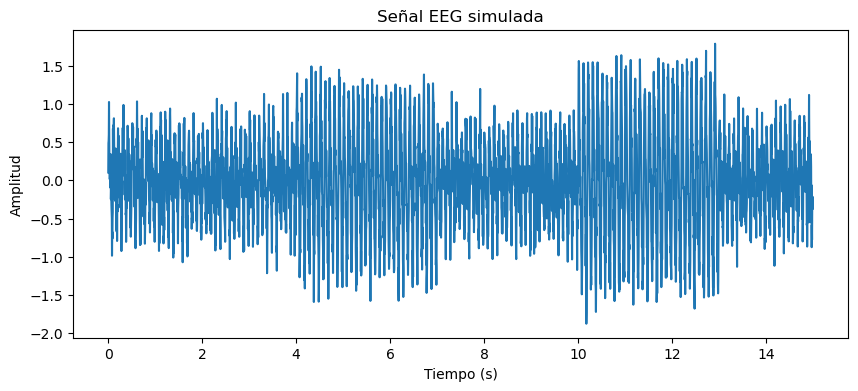

In [45]:
plt.figure(figsize=(10, 4))
plt.plot(t, eeg)
plt.title("Señal EEG simulada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

## 3. Filtro pasa banda (Alpha 8–12 Hz)

In [46]:
def filtro_pasabanda(signal, low, high, fs, order=4):
    nyq = 0.5 * fs
    low = low / nyq
    high = high / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

alpha_filtrada = filtro_pasabanda(eeg, 8, 12, fs)

## 4. Visualización de la señal filtrada

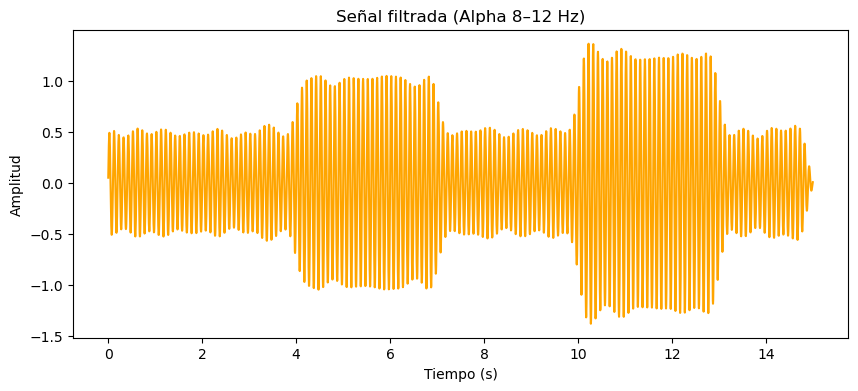

In [47]:
plt.figure(figsize=(10, 4))
plt.plot(t, alpha_filtrada, color='orange')
plt.title("Señal filtrada (Alpha 8–12 Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

## 5. Cálculo del nivel de atención

Se usa la energía (potencia) calculada en ventanas deslizantes sobre la señal Alpha filtrada.

In [48]:
ventana = int(0.5 * fs)  # 0.5 segundos
potencia = np.zeros_like(alpha_filtrada)

for i in range(len(alpha_filtrada)):
    inicio = max(0, i - ventana // 2)
    fin = min(len(alpha_filtrada), i + ventana // 2)
    potencia[i] = np.mean(alpha_filtrada[inicio:fin] ** 2)

# Normalizar entre 0 y 1
potencia = potencia / np.max(potencia)

## 6. Umbral y condición BCI

In [49]:
umbral = np.mean(potencia) + np.std(potencia)

estado = potencia > umbral

## 7. Visualización del nivel de atención

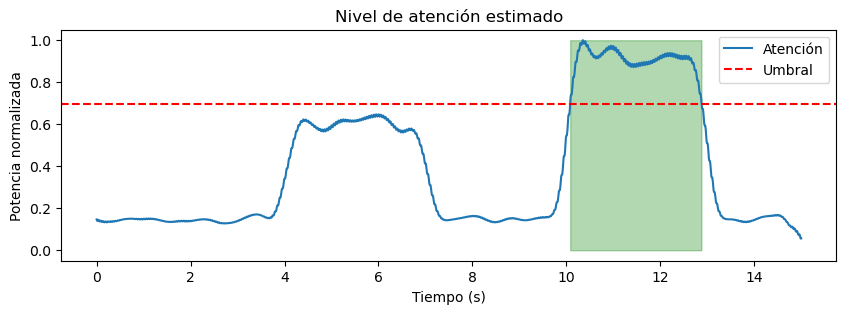

In [50]:
plt.figure(figsize=(10, 3))
plt.plot(t, potencia, label="Atención")
plt.axhline(umbral, color='red', linestyle='--', label="Umbral")
plt.fill_between(t, 0, 1, where=estado, alpha=0.3, color='green')
plt.legend()
plt.title("Nivel de atención estimado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Potencia normalizada")
plt.show()

## 8. Simulación visual BCI

Se evalúa el último valor de potencia para determinar el estado de atención y mostrarlo visualmente.

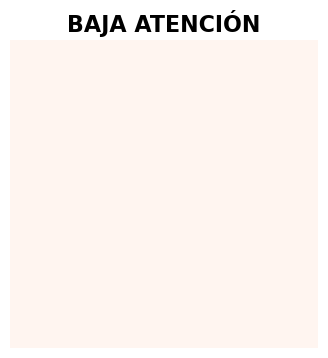

In [51]:
# Estado actual (último valor)
nivel_actual = potencia[-1]

if nivel_actual > umbral:
    color = "Greens"
    texto = "ALTA ATENCIÓN"
else:
    color = "Reds"
    texto = "BAJA ATENCIÓN"

plt.figure(figsize=(4, 4))
plt.imshow([[1, 1], [1, 1]], cmap=color)
plt.title(texto, fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

## BONUS – Animación en tiempo real del nivel de atención

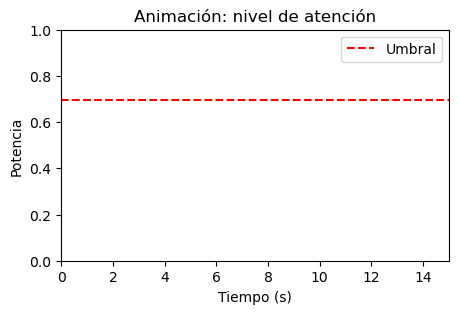

In [53]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(5, 3))
line, = ax.plot([], [], lw=2, color='steelblue')
ax.set_xlim(0, duracion)
ax.set_ylim(0, 1)
ax.axhline(umbral, color='red', linestyle='--', label='Umbral')
ax.set_title("Animación: nivel de atención")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Potencia")
ax.legend()

def update(frame):
    x = t[:frame]
    y = potencia[:frame]
    line.set_data(x, y)
    return line,

ani = animation.FuncAnimation(fig, update, frames=len(t), interval=20, blit=True)

plt.show()